# Stroj - Primeiro Challenge - Dataset

In [123]:
import pandas as pd
import matplotlib.pyplot as plt
import re

## Pré processamento dos datasets

### Dataset 1 - Fake.br Corpus

Corpus Fake News em Português
Corpus para detecção automática de fake news em português, organizado em três versões:
- full_texts → textos completos + metadados de notícias fake e true.
- size_normalized_texts → pares fake/true com textos equalizados em número de palavras, reduzindo viés nos experimentos de ML.
- preprocessed → CSV com textos pré-processados (stopwords, acentos/diacríticos removidos).

Os pares fake/true são identificados pelo mesmo número/nome.
Metadados: autoria, categoria, data, tamanho textual, verbos, substantivos, adjetivos, pronomes, emotividade, diversidade etc.

Referências principais: Monteiro et al. (2018) — PROPOR; Silva et al. (2020) — Expert Systems with Applications.

In [124]:
df1 = pd.read_csv("input_datasets/pre-processed.csv")
df1 = df1.drop(columns=['index'])
df1 = df1.rename(columns={'preprocessed_news':'text'})
df1['label'] = df1['label'].map({'fake':0,'true':1})
df1 = df1.drop_duplicates()
df1

,label,text
0,0,katia abreu diz vai colocar expulsao moldura n...
1,0,ray peita bolsonaro conservador fake entrevist...
2,0,reinaldo azevedo desmascarado policia federal ...
3,0,relatorio assustador bndes mostra dinheiro pub...
4,0,radialista americano fala sobre pt vendem ilus...
...,...,...
7195,1,jornal britanico acao contra lula lava jato se...
7196,1,temer diz acionou pf cade investigar aumentos ...
7197,1,obstaculos politicos temer especialistas ouvid...
7198,1,setembro boa noite aqui estao principais notic...


### Dataset 2 - FakeTrue.Br



FakeTrueBr is a corpus that contains a collection of fake and true news, carefully aligned with each other. Each fake news article in the corpus has its corresponding true news article that is thematically related. In total, this corpus includes 3582 news articles.

The fake news articles were collected from the verification agency Boatos.org using a crawler, allowing us to gather a diverse sample of fake news. Additionally, we developed a methodology and a custom crawler to extract news articles that were topically related to the previously collected fake news. These true news articles were collected from trustworthy journalistic sources such as G1 Globo and Folha de S.Paulo.

If you're interested in learning more details about the creation of this corpus or the classification results we obtained, we invite you to consult our publication presented at the XVIII Escola Regional de Banco de Dados. You can access the full article here.

In [125]:
df2 = pd.read_csv("input_datasets/FakeTrueBr_corpus.csv")
df2 = df2.drop(columns=['title_fake', 'link_f', 'link_t'])
df2 = pd.concat([
    df2[["fake"]].rename(columns={"fake": "text"}).assign(label=0),
    df2[["true"]].rename(columns={"true": "text"}).assign(label=1)
], ignore_index=True)
df2 = df2.drop_duplicates()
df2

,text,label
0,carnaval em olinda. arrastão monstro. fazuele ...,0
1,carro alegórico da escola de samba grande rio...,0
2,cantor léo apoiando atos antidemocráticos. alg...,0
3,versão 1 ore muito pela cantora anitta! ela es...,0
4,morre erasmo carlos aos 81 anos cantor conside...,0
...,...,...
3577,O preço médio da gasolina nos postos do Brasi...,1
3578,Não há nenhuma comprovação que vacinas contra...,1
3579,A seringa que foi usada por uma técnica de en...,1
3580,A SESAI (Secretaria Especial de Saúde Indígen...,1


### Dataset 3 - Fake news in Portuguese

Dataset containing 20k news records categorized as fake news and 2k news classified as true.

It was separated into two spreadsheets, one containing only fake news (label = 1) and the other containing only true news (label = 0).

In [126]:
df3_fake = pd.read_csv("input_datasets/fakes.csv")
df3_true = pd.read_csv("input_datasets/true.csv")
df3_fake["label"] = 0
df3_true["label"] = 1
df3 = pd.concat([df3_fake, df3_true], ignore_index=True)
df3 = df3.drop(columns=['title', 'origin', 'url', 'publisher_name', 'publisher_site', 'date'])
df3 = df3.drop_duplicates()
df3

,text,label
0,“Nando Reis se F… Se F…. no Rock in Rio”,0
1,"“Não foi dinheiro vivo. Moeda corrente, quer d...",0
2,"“Em seus últimos momentos de vida, rainha Eliz...",0
3,“TSE MARCOU PARA PRÓXIMA SEMANA JULGAMENTO OND...,0
4,"De repente, a Ivermectina aparece no site do N...",0
...,...,...
23193,Teste em cão dá positivo para o novo coronavírus,1
23194,Está com suspeita de coronavírus leva o kit pr...,1
23195,Bolsonaro afirmou em 2018 que o indulto de Nat...,1
23196,Jair Bolsonaro declarou que a chegada de Hugo ...,1


## Junção dos datasets

In [127]:
df = pd.concat([df3], ignore_index=True) #TODO: Usar outros datasets
df

,text,label
0,“Nando Reis se F… Se F…. no Rock in Rio”,0
1,"“Não foi dinheiro vivo. Moeda corrente, quer d...",0
2,"“Em seus últimos momentos de vida, rainha Eliz...",0
3,“TSE MARCOU PARA PRÓXIMA SEMANA JULGAMENTO OND...,0
4,"De repente, a Ivermectina aparece no site do N...",0
...,...,...
23114,Teste em cão dá positivo para o novo coronavírus,1
23115,Está com suspeita de coronavírus leva o kit pr...,1
23116,Bolsonaro afirmou em 2018 que o indulto de Nat...,1
23117,Jair Bolsonaro declarou que a chegada de Hugo ...,1


### Balanceamento do dataset - teste

In [ ]:
n = 2717

df["word_count"] = df["text"].str.split().str.len()

bins = [0, 10, 20, 30, 40, 50, 75, 100, 150, 200, 300, 500, 1000, float("inf")]

df["word_bin"] = pd.cut(
    df["word_count"],
    bins=bins,
    right=False
)

df_falsos = df[df["label"] == 0]

amostras = []

distribuicao_true = (
    df[df["label"] == 1]["word_bin"]
    .value_counts(normalize=True)
    .sort_index()
)

for faixa, proporcao in distribuicao_true.items():
    quantidade = round(n * proporcao)

    candidatos = df_falsos[df_falsos["word_bin"] == faixa]

    quantidade = min(quantidade, len(candidatos))

    amostras.append(
        candidatos.sample(
            n=quantidade,
            random_state=42
        )
    )

df_falsos_balanceados = pd.concat(amostras)

df_verdadeiros = df[df["label"] == 1]

df = pd.concat([
    df_verdadeiros,
    df_falsos_balanceados
])

df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

#### Informações sobre o dataset

Quantidade de notícias: 5434 (fake: 2717, true: 2717)
Quantidade de dados duplicados: 0
Quantidade de dados vazios: 0


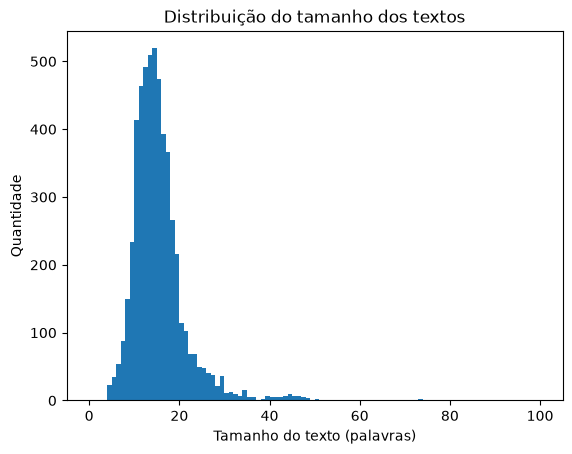

Quantidade de notícias: 5434 (fake: 2717, true: 2717)
Quantidade de dados duplicados: 0
Quantidade de dados vazios: 0


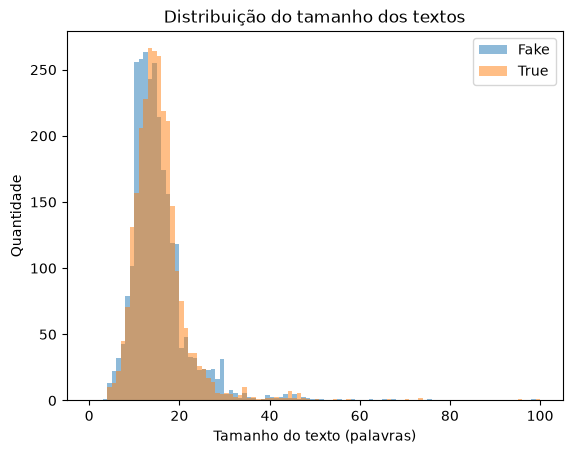

In [129]:
print(f"Quantidade de notícias: {df.shape[0]} (fake: {df['label'].value_counts()[0]}, true: {df['label'].value_counts()[1]})")
print(f"Quantidade de dados duplicados: {df["text"].duplicated().sum()}")
print(f"Quantidade de dados vazios: {df.isnull().sum().sum()}")
tamanhos = df["text"].str.split().str.len()
plt.hist(tamanhos, bins=list(range(0, 101, 1)))
plt.xlabel("Tamanho do texto (palavras)")
plt.ylabel("Quantidade")
plt.title("Distribuição do tamanho dos textos")
plt.show()

print(
    f"Quantidade de notícias: {df.shape[0]} "
    f"(fake: {df['label'].value_counts()[0]}, "
    f"true: {df['label'].value_counts()[1]})"
)

print(f"Quantidade de dados duplicados: {df['text'].duplicated().sum()}")

print(f"Quantidade de dados vazios: {df.isnull().sum().sum()}")

tamanhos = df["text"].str.split().str.len()

tamanhos_fake = tamanhos[df["label"] == 0]
tamanhos_true = tamanhos[df["label"] == 1]

plt.hist(
    tamanhos_fake,
    bins=list(range(0, 101, 1)),
    alpha=0.5,
    label="Fake"
)

plt.hist(
    tamanhos_true,
    bins=list(range(0, 101, 1)),
    alpha=0.5,
    label="True"
)

plt.xlabel("Tamanho do texto (palavras)")
plt.ylabel("Quantidade")
plt.title("Distribuição do tamanho dos textos")
plt.legend()

plt.show()

## Pós processamento dos datasets

In [130]:
textos = df["text"]

# 1. Caixa alta é predominante
# Considera apenas letras e verifica se mais de 50% estão em maiúsculas
def caixa_alta_predominante(text):
    letras = [c for c in text if c.isalpha()]
    
    if not letras:
        return False
    
    maiusculas = sum(c.isupper() for c in letras)
    return maiusculas / len(letras) > 0.5


# 2. Mais de um ponto de exclamação seguido
def multiplas_exclamacoes(text):
    return bool(re.search(r"!{2,}", text))


# 3. Mais de um ponto de interrogação seguido
def multiplas_interrogacoes(text):
    return bool(re.search(r"\?{2,}", text))


# 4. Caracteres especiais
def possui_caracteres_especiais(text):
    return bool(re.search(r"[@$%*_+=<>|~^]", text))


# Criar características
df_analise = pd.DataFrame({
    "label": df["label"],
    "caixa_alta": textos.apply(caixa_alta_predominante),
    "multiplas_exclamacoes": textos.apply(multiplas_exclamacoes),
    "multiplas_interrogacoes": textos.apply(multiplas_interrogacoes),
    "caracteres_especiais": textos.apply(possui_caracteres_especiais)
})

# Quantidade por label
print("QUANTIDADE DE TEXTOS COM CADA CARACTERÍSTICA")
print("=" * 60)

print(
    df_analise
    .groupby("label")
    .sum(numeric_only=True)
)


# Porcentagem por label
print("\n\nPORCENTAGEM DE TEXTOS COM CADA CARACTERÍSTICA")
print("=" * 60)

print(
    df_analise
    .groupby("label")
    .mean(numeric_only=True)
    .mul(100)
    .round(2)
)

QUANTIDADE DE TEXTOS COM CADA CARACTERÍSTICA
       caixa_alta  multiplas_exclamacoes  multiplas_interrogacoes  \
label                                                               
0              49                     34                       12   
1               6                      3                        0   

       caracteres_especiais  
label                        
0                       247  
1                       325  


PORCENTAGEM DE TEXTOS COM CADA CARACTERÍSTICA
       caixa_alta  multiplas_exclamacoes  multiplas_interrogacoes  \
label                                                               
0            1.80                   1.25                     0.44   
1            0.22                   0.11                     0.00   

       caracteres_especiais  
label                        
0                      9.09  
1                     11.96  


In [131]:
# Adicionar as colunas ao DataFrame original
df["caixa_alta"] = textos.apply(caixa_alta_predominante).map({False:0,True:1})
df["multiplas_exclamacoes"] = textos.apply(multiplas_exclamacoes).map({False:0,True:1})
df["multiplas_interrogacoes"] = textos.apply(multiplas_interrogacoes).map({False:0,True:1})
df["caracteres_especiais"] = textos.apply(possui_caracteres_especiais).map({False:0,True:1})
df

,text,label,word_count,word_bin,caixa_alta,multiplas_exclamacoes,multiplas_interrogacoes,caracteres_especiais
0,Trabalhadores expostos a riscos terão adiciona...,0,11,"[10.0, 20.0)",0,0,0,1
1,Music-Check. “Girl You’ll Be a Woman Soon” é d...,0,11,"[10.0, 20.0)",0,0,0,0
2,"Catarina Martins: ""Iniciativa Liberal propôs e...",1,15,"[10.0, 20.0)",0,0,0,0
3,No edital do [concurso para a] Polícia Civil d...,1,22,"[20.0, 30.0)",0,0,0,0
4,Câmara de Lisboa cria novo centro para sem-abr...,0,15,"[10.0, 20.0)",0,0,0,0
...,...,...,...,...,...,...,...,...
5429,Policias apreendem dinheiro na casa do secretá...,0,12,"[10.0, 20.0)",0,0,0,0
5430,A CIA (Polícia secreta americana) divulga list...,0,22,"[20.0, 30.0)",0,0,1,0
5431,"EX-SENADOR PELO PT, LINDENBERG FARIAS, É FLAGR...",0,29,"[20.0, 30.0)",1,0,0,1
5432,Art. 1º – Criar o TRIBUNAL CONSTITUCIONAL MILI...,0,34,"[30.0, 40.0)",0,0,0,0


## Exportação do dataset

In [132]:
df.to_csv('dataset.csv', index_label="id")

## Dataset de teste

In [133]:
df_teste = pd.read_csv("input_datasets/fakerecogna_extrativo.csv")
df_teste = df_teste.drop(columns=['Unnamed: 0', 'Titulo', 'Categoria', 'Autor', 'Data', 'URL', 'Subtitulo'])
df_teste = df_teste.rename(columns={'Noticia':'text', 'Label':'label'})
df_teste['label'] = df_teste['label'].map({1:0,0:1})
"""
df_teste_verdadeiro = df_teste[df_teste['label'] == 1]
df_teste_verdadeiro = df_teste_verdadeiro.sample(n=100)
#df_teste_verdadeiro = df_teste_verdadeiro.drop(columns=['label'])
df_teste_falso = df_teste[df_teste['label'] == 0]
df_teste_falso = df_teste_falso.sample(n=100)
#df_teste_falso = df_teste_falso.drop(columns=['label'])
"""

df_teste["word_count"] = df_teste["text"].str.split().str.len()
df_teste["distancia_90"] = (df_teste["word_count"] - 90).abs()

df_teste_verdadeiro = (
    df_teste[df_teste["label"] == 1]
    .sort_values("distancia_90")
    .head(100)
)

df_teste_falso = (
    df_teste[df_teste["label"] == 0]
    .sort_values("distancia_90")
    .head(100)
)

df_teste_verdadeiro = df_teste_verdadeiro[["text", "label"]]
df_teste_falso = df_teste_falso[["text", "label"]]

df_teste = pd.concat(
    [df_teste_verdadeiro, df_teste_falso],
    ignore_index=True
)

df_teste.to_csv('teste.csv', index_label="id")
df_teste

,text,label
0,"a mesma equipe de cientistas que previu, em ar...",1
1,a principal via pública de uma cidade históric...,1
2,a fundação oswaldo cruz (fiocruz) adiou do iní...,1
3,todas as denúncias de pessoas que estão furand...,1
4,os depoimentos de 12 médicos da prevent senior...,1
...,...,...
195,publicação tira de contexto fala do presidente...,0
196,“o ex presidente do brasil o senhor luiz inaci...,0
197,novo assassino inseto (ver foto). se você já v...,0
198,dez por cento da população brasileira diz que ...,0


Quantidade de notícias: 200 (fake: 100, true: 100)
Quantidade de dados duplicados: 0
Quantidade de dados vazios: 0


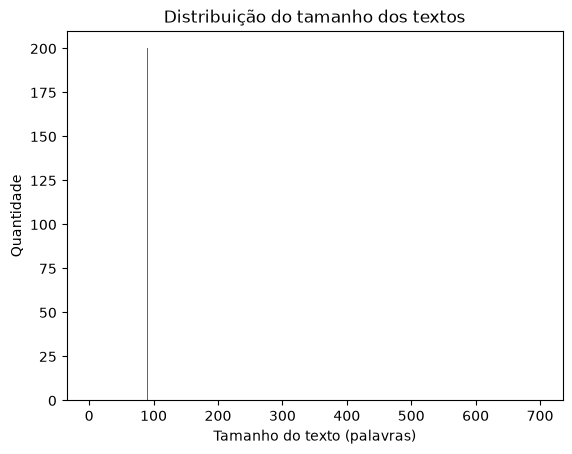

Quantidade de notícias: 200 (fake: 100, true: 100)
Quantidade de dados duplicados: 0
Quantidade de dados vazios: 0


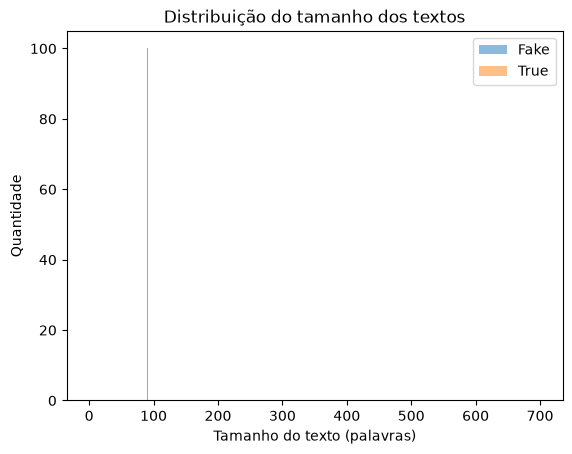

In [134]:
print(f"Quantidade de notícias: {df_teste.shape[0]} (fake: {df_teste['label'].value_counts()[0]}, true: {df_teste['label'].value_counts()[1]})")
print(f"Quantidade de dados duplicados: {df_teste["text"].duplicated().sum()}")
print(f"Quantidade de dados vazios: {df_teste.isnull().sum().sum()}")
tamanhos = df_teste["text"].str.split().str.len()
plt.hist(tamanhos, bins=list(range(0, 701, 1)))
plt.xlabel("Tamanho do texto (palavras)")
plt.ylabel("Quantidade")
plt.title("Distribuição do tamanho dos textos")
plt.show()

print(
    f"Quantidade de notícias: {df_teste.shape[0]} "
    f"(fake: {df_teste['label'].value_counts()[0]}, "
    f"true: {df_teste['label'].value_counts()[1]})"
)

print(f"Quantidade de dados duplicados: {df_teste['text'].duplicated().sum()}")

print(f"Quantidade de dados vazios: {df_teste.isnull().sum().sum()}")

tamanhos = df_teste["text"].str.split().str.len()

tamanhos_fake = tamanhos[df_teste["label"] == 0]
tamanhos_true = tamanhos[df_teste["label"] == 1]

plt.hist(
    tamanhos_fake,
    bins=list(range(0, 701, 1)),
    alpha=0.5,
    label="Fake"
)

plt.hist(
    tamanhos_true,
    bins=list(range(0, 701, 1)),
    alpha=0.5,
    label="True"
)

plt.xlabel("Tamanho do texto (palavras)")
plt.ylabel("Quantidade")
plt.title("Distribuição do tamanho dos textos")
plt.legend()

plt.show()